In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.svm import SVC
from sklearn.neural_network import MLPRegressor

In [2]:
import sys
sys.path.append("/Users/mariahloehr/IICD/IICD/feature_importance")

In [3]:
import locomp
from locomp import *
from locomp.MLmodels import *
from locomp.util_locomp import *
import itertools
import importlib
from sklearn.base import BaseEstimator, RegressorMixin, clone
import itertools
from functools import partial
import multiprocessing as mp
import re

import functions_case as il
import importlib

import functions_tertiary as il3
import comprehensive_functions as comp

In [6]:
# Load data
df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Data/cell_cycle_tidied.csv")

# Define features and target
X = df.drop(columns=['phase', 'age', 'PHATE_1', 'PHATE_2'])  # Features
y = df['age']  # Target: age

# define models
DecisionTreeReg = DecisionTreeRegressor(max_depth = 20, 
                                 max_features=150,
                                 random_state=949
                                 )

In [7]:
models = [DecisionTreeReg]

In [8]:
J1 = 0
J2 = 1
m_ratio = 0.5
n_ratio = 0.5
B = 5000

In [9]:
mp_ensemble = comp.mp_ensemble(X, y, n_ratio, m_ratio, B, models, adjust_col=None)

In [10]:
np.savez("pdp_ensemble_rf.npz", ensemble = mp_ensemble['ensemble'], predictions=mp_ensemble['predictions'], obs=mp_ensemble['mp_observations'], feats=mp_ensemble['mp_features'])

In [4]:
# Load data
df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Cancer treatment/T47D.csv")

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Separate features and target
X = df.drop(columns=['phase'])
y = le.fit_transform(df['phase'])
adjust_col = X.columns.get_loc("Metadata_well")

feature_names = X.columns.tolist()
feature_pairs = list(itertools.combinations(range(X.shape[1]), 2))
feature_triplets = list(itertools.combinations(range(X.shape[1]), 3))

In [5]:
DecisionTreeClass = DecisionTreeClassifier(max_depth = 50, 
                                 max_features=10,
                                 random_state=949
                                 )

In [6]:
xgbclass = GradientBoostingClassifier(
        n_estimators=10,       # fixed boosting rounds
        learning_rate=0.1, # hyperparameters from XGB model
        max_depth=7,
        random_state=949
    )

In [7]:
# Define RBF-kernel SVM
svmclass = svm_model = SVC(
    kernel='rbf',
    C=1.0,              
    gamma='scale',
    probability=True,
    random_state=949
)

In [8]:
J1 = 0
J2 = 1
m_ratio = 0.2
n_ratio = 0.2
B = 10
models = [DecisionTreeClass, xgbclass, svmclass]
adjust_col = adjust_col

In [9]:
mp_ensemble = comp.mp_ensemble(X, y, n_ratio, m_ratio, B, models, adjust_col=None)

In [10]:
feature_groups = comp.make_feature_groups(X, order=3, include_col=None, subset=None)

In [11]:
mp_results = comp.featureInteractions(X, y, mp_ensemble, feature_groups, order=3, type = "classification", bonferroni = True)

In [15]:
mp_features = [mp_results[(i, j, k)]['features'] for (i,j, k) in feature_groups]
mp_scores = [mp_results[(i, j, k)]['iloco'] for (i,j, k) in feature_groups]
mp_ci = [mp_results[(i, j, k)]["ci"] for (i, j, k) in feature_groups]

In [16]:
data = {'feature': mp_features, 'scores': mp_scores, 'ci': mp_ci }
df = pd.DataFrame(data)

In [17]:
top_20 = df.nlargest(10, "scores")

/var/folders/1s/bvxr71hj0hqgyk_jk6k7wkm80000gn/T/ipykernel_26966/3419943142.py:39: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


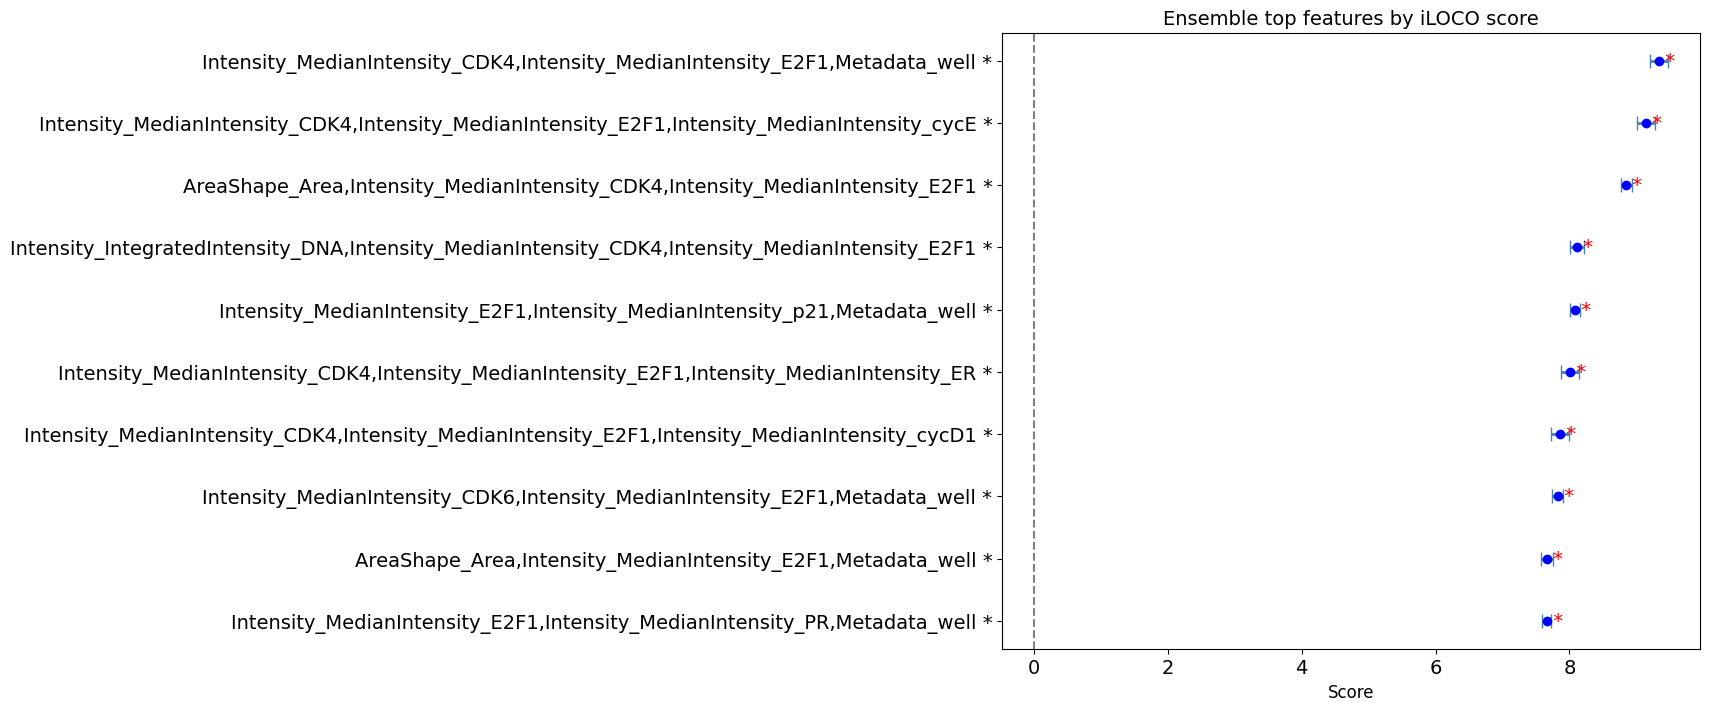

In [18]:
# Plot
# Copy feature names so we can modify them without affecting the original DataFrame
ytick_labels = top_20["feature"].copy()

# Add star next to feature names if CI does not include zero
for i, (score, ci) in enumerate(zip(top_20["scores"], top_20["ci"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:
        ytick_labels.iloc[i] += " *"

plt.figure(figsize=(9, 8))
plt.errorbar(
    top_20["scores"],
    top_20["feature"],
    xerr=top_20["ci"],
    fmt='o',  # Point marker
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)
plt.axvline(x=0, color='gray', linestyle='--')
plt.xticks(fontsize=14)  # Rotate x-axis labels vertically
plt.xlabel("Score", fontsize=12)
plt.title("Ensemble top features by iLOCO score", fontsize=14)

# Add stars for scores whose confidence intervals do not include 0
for i, (score, ci, feature) in enumerate(zip(top_20["scores"], top_20["ci"], top_20["feature"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:  # CI does not include 0
        plt.text(score, feature, " *", color='red', fontsize=14, va='center')

plt.yticks(ticks=top_20["feature"], labels=ytick_labels, fontsize=14)

plt.gca().invert_yaxis()  # Reverse y-axis

plt.tight_layout()
plt.show()

TOP 40

In [14]:
# Load data
df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Data/top40_cell_cycle.csv")

# Define features and target
X = df.drop(columns=['phase', 'age'])  # Features
y = df['age']  # Target: age

# define models
DecisionTreeReg = DecisionTreeRegressor(max_depth = 20, 
                                 max_features=150,
                                 random_state=949
                                 )

MLPreg = MLPRegressor(max_iter=200,
                       random_state=949,
                       hidden_layer_sizes = (150,150,150),
                       learning_rate = 'adaptive', 
                       learning_rate_init = 0.001, 
                       alpha = 25)

xgbreg = GradientBoostingRegressor(
        n_estimators=10,       # fixed boosting rounds
        learning_rate=0.5, # hyperparameters from XGB model
        max_depth=5,
        random_state=949
    )

models = [DecisionTreeReg, MLPreg, xgbreg]

J1 = 0
J2 = 1
m_ratio = 0.5
n_ratio = 0.5
B = 5000

mp_ensemble = comp.mp_ensemble(X, y, n_ratio, m_ratio, B, models, adjust_col=None)

feature_groups = comp.make_feature_groups(X, order=2, include_col=None, subset=None)

mp_results = comp.featureInteractions(X, y, mp_ensemble, feature_groups, order=2, type = "regression", bonferroni = True)

np.savez("ensemble_top40.npz", ensembles= mp_ensemble['ensemble'], predictions=mp_ensemble['predictions'], obs=mp_ensemble['mp_observations'], feats=mp_ensemble['mp_features'])

mp_results.to_csv("iloco_ensemble_top40.csv", index=False)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (5000,) + inhomogeneous part.

In [27]:
import pickle

with open("ensemble_top40.pkl", "wb") as f:
    pickle.dump(mp_ensemble, f)

In [25]:
df = pd.DataFrame.from_dict(mp_results, orient='index')
df.to_csv("iloco_ensemble_top40.csv", index=False)

In [17]:
mp_ensemble

{'predictions': array([[12.69681439,  9.46702222, 10.26317333, ...,  7.20452494,
          9.36399088, 10.97295014],
        [12.62776209, 12.10964444, 12.39921956, ..., 13.4302995 ,
         14.48665259, 12.57338507],
        [ 4.72163854, 10.4       ,  4.78549333, ...,  5.66138399,
          4.12008169,  5.516186  ],
        ...,
        [ 2.98882995,  1.15577224,  1.68389333, ...,  2.75558591,
          1.31603553,  1.83559817],
        [14.87601127, 12.22577778, 12.22577778, ..., 11.50202424,
         10.55344708, 14.34581911],
        [ 4.52513312,  3.95698667,  4.09110667, ...,  3.15246391,
          2.24071982,  3.42143644]], shape=(8850, 5000)),
 'mp_observations': array([[False, False,  True, ...,  True,  True, False],
        [False,  True,  True, ..., False, False,  True],
        [ True, False, False, ..., False,  True, False],
        ...,
        [ True, False,  True, ...,  True,  True, False],
        [ True,  True,  True, ..., False,  True, False],
        [False,  True

In [23]:
mp_results

{(0, 1): {'features': 'E2F1..nuc.median.,cycA..nuc.median.',
  'iloco': np.float64(-0.006084585502426229),
  'iloco_max': 0,
  'iloco_ratio': np.float64(-0.0028522393852171853),
  'ci': np.float64(0.019687735208248642)},
 (0, 2): {'features': 'E2F1..nuc.median.,cycD1..nuc.median.',
  'iloco': np.float64(-0.008252611635707242),
  'iloco_max': 0,
  'iloco_ratio': np.float64(-0.00386853367889725),
  'ci': np.float64(0.019687735208248642)},
 (0, 3): {'features': 'E2F1..nuc.median.,p21..nuc.median.',
  'iloco': np.float64(-0.01727608111377593),
  'iloco_max': 0,
  'iloco_ratio': np.float64(-0.008098418364779304),
  'ci': np.float64(0.019687735208248642)},
 (0, 4): {'features': 'E2F1..nuc.median.,Int_Intg_DNA_nuc',
  'iloco': np.float64(0.009251224179650401),
  'iloco_max': np.float64(0.009251224179650401),
  'iloco_ratio': np.float64(0.004336648068492211),
  'ci': np.float64(0.019687735208248642)},
 (0, 5): {'features': 'E2F1..nuc.median.,Skp2..nuc.median.',
  'iloco': np.float64(-0.0083238

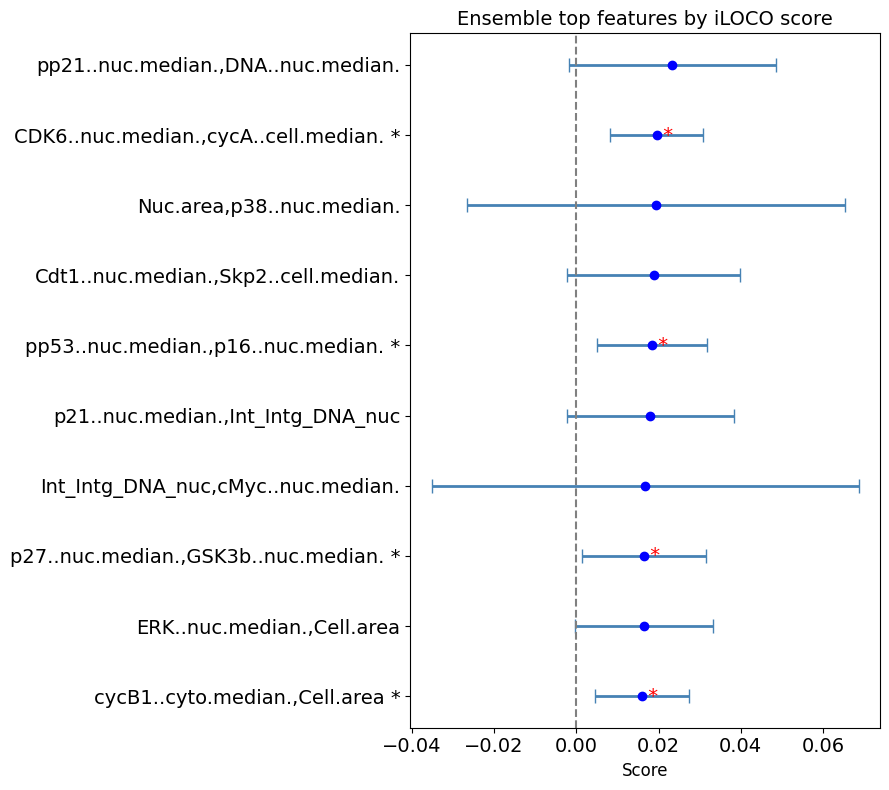

In [18]:
mp_features = [mp_results[(i, j)]['features'] for (i,j) in feature_groups]
mp_scores = [mp_results[(i, j)]['iloco'] for (i,j) in feature_groups]
mp_ci = [mp_results[(i, j)]["ci"] for (i, j) in feature_groups]

data = {'feature': mp_features, 'scores': mp_scores, 'ci': mp_ci }
df = pd.DataFrame(data)

top_20 = df.nlargest(10, "scores")

# Plot
# Copy feature names so we can modify them without affecting the original DataFrame
ytick_labels = top_20["feature"].copy()

# Add star next to feature names if CI does not include zero
for i, (score, ci) in enumerate(zip(top_20["scores"], top_20["ci"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:
        ytick_labels.iloc[i] += " *"

plt.figure(figsize=(9, 8))
plt.errorbar(
    top_20["scores"],
    top_20["feature"],
    xerr=top_20["ci"],
    fmt='o',  # Point marker
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)
plt.axvline(x=0, color='gray', linestyle='--')
plt.xticks(fontsize=14)  # Rotate x-axis labels vertically
plt.xlabel("Score", fontsize=12)
plt.title("Ensemble top features by iLOCO score", fontsize=14)

# Add stars for scores whose confidence intervals do not include 0
for i, (score, ci, feature) in enumerate(zip(top_20["scores"], top_20["ci"], top_20["feature"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:  # CI does not include 0
        plt.text(score, feature, " *", color='red', fontsize=14, va='center')

plt.yticks(ticks=top_20["feature"], labels=ytick_labels, fontsize=14)

plt.gca().invert_yaxis()  # Reverse y-axis

plt.tight_layout()
plt.show()